In [ ]:
from pathlib import Path
from detector_pipeline import AutomatedDetectorPipeline, generate_plot
import h5py
import numpy as np



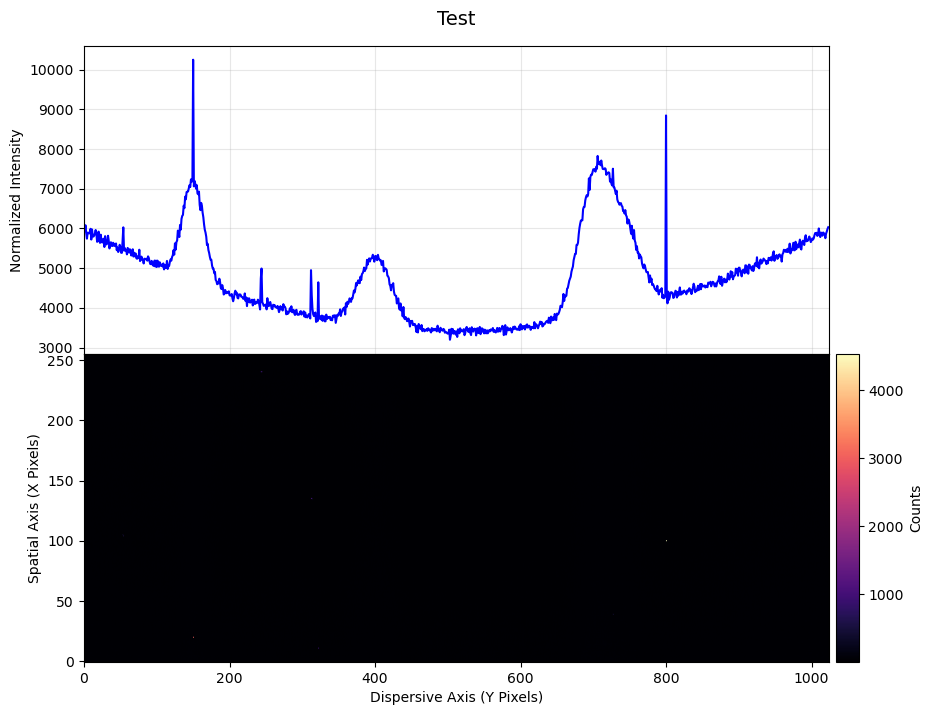

In [ ]:
# Manually load single file
with h5py.File("synthetic_data/scan_0001.h5", 'r') as hf:
    raw_2d = hf['entry/data/counts'][:].astype(np.float64)

# Integrate it down to 1D
raw_1d = np.sum(raw_2d, axis=0) # Change to axis=1 if using horizontal

#Plot the result 

fig = generate_plot(
                data_1d = raw_1d,
                data_2d = raw_2d,
                integration_axis = 'horizontal',
                title = "Test",
            )

2026-03-27 15:51:47,608 | INFO | Loaded and sliced master dark: dark_background.h5


2026-03-27 15:51:47,648 | INFO | Sufficient files buffered...
2026-03-27 15:51:47,655 | INFO | [INIT] scan_0001.h5


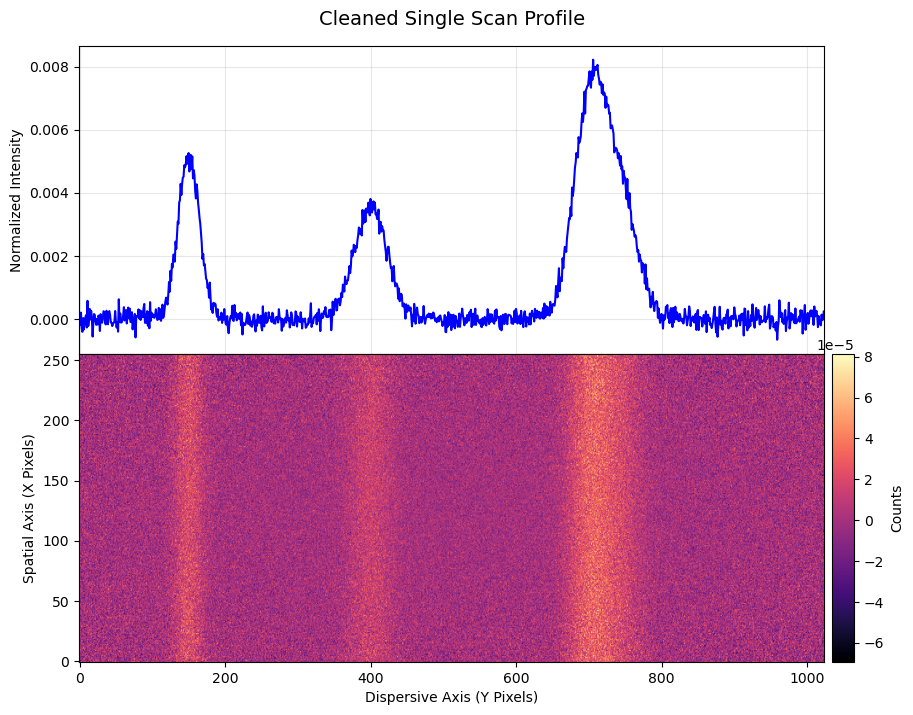

In [ ]:
# The pipeline can be used to quick work up a single scan
# Initialize the pipeline
pipe = AutomatedDetectorPipeline("config.yaml")

# Force it to process instantly without waiting for a buffer
pipe.min_init_scans = 1 

# Viewing a single file
pipe.process_file(Path("synthetic_data/scan_0001.h5"))

fig = generate_plot(
    data_1d = pipe.running_mean_norm,
    data_2d = pipe.running_mean_2d_norm,
    title = "Cleaned Single Scan Profile",
    integration_axis = pipe.integration_axis,
)

2026-03-27 15:55:39,538 | INFO | Loaded and sliced master dark: dark_background.h5


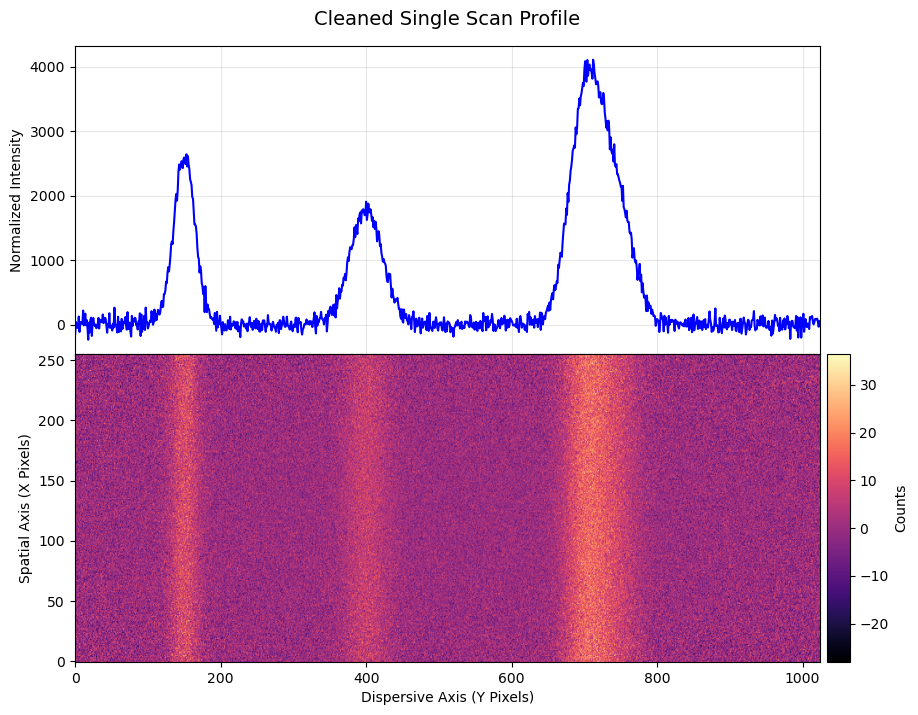

In [ ]:
# 1. Load the pipeline to get access to the cleaning tools & dark subtraction
pipe = AutomatedDetectorPipeline("config.yaml")
#Grab axis = 0/1 for below, without having to manually change it
axis_num = {"vertical": 0, "horizontal": 1}[pipe.integration_axis]
# 2. Pick the files to average
files_to_average = [
    Path("synthetic_data/scan_0003.h5"), 
    Path("synthetic_data/scan_0002.h5"),
]

cleaned_2d_list = []
cleaned_1d_list = []

# 3. Clean each file individually
for f_path in files_to_average:
    with h5py.File(f_path, 'r') as hf:
        raw_2d = hf['entry/data/counts'][:].astype(np.float64)
        
    # Clean, Dark Subtract, and Despike
    safe_2d = pipe._clean_data(raw_2d)
    if pipe.master_dark is not None:
        safe_2d -= pipe.master_dark
            
    clean_2d = pipe._remove_cosmic_rays(safe_2d)
    
    # Integrate down to 1D (change axis=1 if using horizontal integration)
    clean_1d = np.sum(clean_2d, axis=axis_num) 
    
    # Store the  arrays
    cleaned_2d_list.append(clean_2d)
    cleaned_1d_list.append(clean_1d)
#Final averaging, note axis = 0 here always
final_2d_avg = np.mean(cleaned_2d_list, axis=0)
final_1d_avg = np.mean(cleaned_1d_list, axis=0)

#Plot the result
fig = generate_plot(
    data_1d = final_1d_avg,
    data_2d = final_2d_avg,
    title = "Cleaned Single Scan Profile",
    integration_axis = pipe.integration_axis,
)